In [174]:
%config HistoryManager.enabled = False

# Customer Churn Prediction

# Problem Statement

#### Many businesses face difficulties in understanding customer behavior and identifying the reasons behind payment delays, frequent complaints, low customer activity, and the impact of discounts on revenue. Customer-related data is often stored in different systems, making it difficult to track important business patterns.

#### This project focuses on analyzing customer login frequency, payment delays, discount usage, complaints, and product/service usage trends using SQL and Python. The goal is to find meaningful insights that can help businesses improve customer engagement, reduce delayed payments, handle customer issues effectively, and make better pricing and discount decisions.

#### By studying customer activity and transaction data, the project helps in identifying inactive customers, repeated payment delays, high complaint areas, and usage patterns that affect overall business performance.##

# Wrokflow
http://localhost:8888/files/PYTHON(IIT%20INDORE)/customer_churn_prediction/Workflow.png?_xsrf=2%7Ca5f4c357%7C8ce8950c85c2a38ab5d6cd0bcafe61d9%7C1778743846


In [175]:
import pandas as pd
import sqlite3

# Create database
conn = sqlite3.connect("customer_data.db")

# Read CSV files
logins = pd.read_csv("customer_data/logins.csv")
invoices = pd.read_csv("customer_data/invoices.csv")
purchases = pd.read_csv("customer_data/purchases.csv")
tickets = pd.read_csv("customer_data/tickets.csv")
usage_logs = pd.read_csv("customer_data/usage_logs.csv")
users = pd.read_csv("customer_data/users.csv")

# Upload as SQL tables
logins.to_sql("logins", conn, if_exists="replace", index=False)

invoices.to_sql("invoices", conn, if_exists="replace", index=False)

purchases.to_sql("purchases", conn, if_exists="replace", index=False)

tickets.to_sql("tickets", conn, if_exists="replace", index=False)

usage_logs.to_sql("usage_logs", conn, if_exists="replace", index=False)

users.to_sql("users", conn, if_exists="replace", index=False)


# Save changes
conn.commit()

query = "SELECT name FROM sqlite_master WHERE type='table';"


tables = pd.read_sql(query, conn)

print(tables)



         name
0    purchase
1      logins
2    invoices
3   purchases
4     tickets
5  usage_logs
6       users


In [176]:
query = "select * from logins"

In [177]:
data = pd.read_sql(query, conn)

In [178]:
data

,login_id,user_id,login_time
0,1,1,2026-03-21 10:00:00
1,2,1,2026-03-22 10:00:00
2,3,1,2026-03-26 10:00:00
3,4,1,2026-03-27 10:00:00
4,5,1,2026-04-12 10:00:00
...,...,...,...
227810,227811,10000,2026-05-14 10:00:00
227811,227812,10000,2026-05-15 10:00:00
227812,227813,10000,2026-05-16 10:00:00
227813,227814,10000,2026-05-17 10:00:00


In [179]:
query = """

SELECT
    u.user_id,
    u.username,
    u.signup_date,

    l.total_logins,

    i.total_invoices,
    i.total_invoice_amount,
    i.avg_payment_delay,

    p.total_purchases,
    p.total_purchase_amount,
    p.avg_discount,

    t.total_tickets,
    t.open_tickets,

    ul.avg_usage_hours

FROM users u

LEFT JOIN
(
    SELECT
        user_id,
        COUNT(*) AS total_logins
    FROM logins
    GROUP BY user_id
) l
ON u.user_id = l.user_id

LEFT JOIN
(
    SELECT
        user_id,
        COUNT(*) AS total_invoices,
        SUM(amount) AS total_invoice_amount,

        AVG(
            JULIANDAY(payment_date) - JULIANDAY(due_date)
        ) AS avg_payment_delay

    FROM invoices
    GROUP BY user_id
) i
ON u.user_id = i.user_id

LEFT JOIN
(
    SELECT
        user_id,
        COUNT(*) AS total_purchases,
        SUM(amount) AS total_purchase_amount,
        AVG(discount_value) AS avg_discount

    FROM purchases
    GROUP BY user_id
) p
ON u.user_id = p.user_id

LEFT JOIN
(
    SELECT
        user_id,
        COUNT(*) AS total_tickets,

        SUM(
            CASE
                WHEN status = 'open' THEN 1
                ELSE 0
            END
        ) AS open_tickets

    FROM tickets
    GROUP BY user_id
) t
ON u.user_id = t.user_id

LEFT JOIN
(
    SELECT
        user_id,
        AVG(usage_hours) AS avg_usage_hours

    FROM usage_logs
    GROUP BY user_id
) ul
ON u.user_id = ul.user_id

"""

customer_summary = pd.read_sql(query, conn)

print(customer_summary.head())

   user_id          username signup_date  total_logins  total_invoices  \
0        1     emily_smith_1  2025-10-02          10.0               2   
1        2    karen_taylor_2  2025-08-12          11.0               2   
2        3      jane_smith_3  2025-09-02           6.0               2   
3        4  thomas_jackson_4  2025-09-10          11.0               2   
4        5     james_smith_5  2025-06-11          36.0               2   

   total_invoice_amount  avg_payment_delay  total_purchases  \
0                248.79                0.0                7   
1                258.85                3.5                4   
2                104.34                4.0                7   
3                160.03                1.5                6   
4                262.04               14.5                6   

   total_purchase_amount  avg_discount  total_tickets  open_tickets  \
0                 473.19      0.000000            3.0           0.0   
1                 163.22     15.65

In [180]:
# data handling 
# shape
customer_summary.shape

(10000, 13)

In [181]:
# final table
customer_summary.to_csv(
    "customer_summary.csv",
    index=False
)

In [182]:
customer_summary.head()

,user_id,username,signup_date,total_logins,total_invoices,total_invoice_amount,avg_payment_delay,total_purchases,total_purchase_amount,avg_discount,total_tickets,open_tickets,avg_usage_hours
0,1,emily_smith_1,2025-10-02,10.0,2,248.79,0.0,7,473.19,0.000000,3.0,0.0,1.435246
1,2,karen_taylor_2,2025-08-12,11.0,2,258.85,3.5,4,163.22,15.652500,NaN,NaN,1.847377
2,3,jane_smith_3,2025-09-02,6.0,2,104.34,4.0,7,456.27,0.000000,3.0,0.0,1.397213
3,4,thomas_jackson_4,2025-09-10,11.0,2,160.03,1.5,6,306.39,16.246667,NaN,NaN,1.974754
4,5,james_smith_5,2025-06-11,36.0,2,262.04,14.5,6,284.92,0.000000,2.0,0.0,3.039180


In [17]:
customer_summary.isna().sum()

user_id                     0
username                    0
signup_date                 0
total_logins                1
total_invoices              0
total_invoice_amount        0
avg_payment_delay           0
total_purchases             0
total_purchase_amount       0
avg_discount                0
total_tickets            3282
open_tickets             3282
avg_usage_hours             0
dtype: int64

In [34]:
print(customer_summary.dtypes)

user_id                    int64
username                  object
signup_date               object
total_logins             float64
total_invoices             int64
total_invoice_amount     float64
avg_payment_delay        float64
total_purchases            int64
total_purchase_amount    float64
avg_discount             float64
total_tickets            float64
open_tickets             float64
avg_usage_hours          float64
Cluster                    int32
dtype: object


In [35]:
customer_summary.drop("username", axis=1, inplace=True)

In [41]:
customer_summary.drop("signup_date", axis=1, inplace=True)

In [42]:
# here 3282 users have never raised any complaints/tickets

In [43]:
# convert null value to zero(0)
customer_summary.fillna(0, inplace=True)

In [44]:
customer_summary.isna().sum()

user_id                  0
total_logins             0
total_invoices           0
total_invoice_amount     0
avg_payment_delay        0
total_purchases          0
total_purchase_amount    0
avg_discount             0
total_tickets            0
open_tickets             0
avg_usage_hours          0
Cluster                  0
dtype: int64

# perform customer segmentation using k means clustring

In [45]:
# Import Libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [46]:
# select important feature -- these feature help indentify customer behavior
features = customer_summary[[
    "total_logins",
    "total_invoice_amount",
    "avg_payment_delay",
    "total_purchase_amount",
    "avg_discount",
    "total_tickets",
    "avg_usage_hours"
]]

In [47]:
# scaling the dataset
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [48]:
# find k value using Elbow Method
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

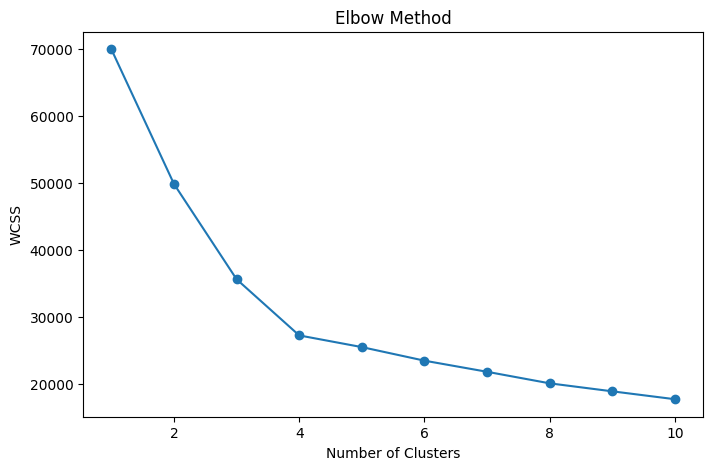

In [49]:
# ploting
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [50]:
# the graph bends around k = 4
# so best number of cluster for K-means is 4

In [51]:
# apply K-means cluster
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_summary["Cluster"] = kmeans.fit_predict(scaled_features)

In [52]:
# cluster counts
customer_summary["Cluster"].value_counts()

Cluster
1    2529
3    2518
2    2485
0    2468
Name: count, dtype: int64

In [53]:
print(customer_summary.dtypes)

user_id                    int64
total_logins             float64
total_invoices             int64
total_invoice_amount     float64
avg_payment_delay        float64
total_purchases            int64
total_purchase_amount    float64
avg_discount             float64
total_tickets            float64
open_tickets             float64
avg_usage_hours          float64
Cluster                    int32
dtype: object


In [54]:
customer_summary.groupby("Cluster").mean()


,user_id,total_logins,total_invoices,total_invoice_amount,avg_payment_delay,total_purchases,total_purchase_amount,avg_discount,total_tickets,open_tickets,avg_usage_hours
Cluster,,,,,,,,,,,
0,5007.995543,45.020665,2.0,178.978505,2.016410,5.514182,327.371613,0.904823,0.493112,0.0,3.677564
1,4962.756425,7.445631,2.0,180.171412,9.016410,5.523527,333.510522,0.000000,3.019375,0.0,1.431301
2,5010.837022,13.690543,2.0,179.866435,1.980684,5.530785,222.326342,20.051293,0.504225,0.0,1.896662
3,5020.860207,25.358618,2.0,180.531612,17.895751,5.485306,328.002943,0.000000,1.008737,0.0,2.999568


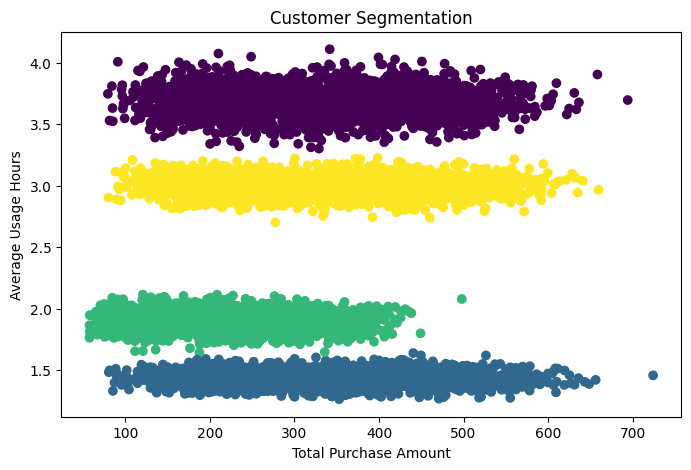

In [55]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_summary["total_purchase_amount"],
    customer_summary["avg_usage_hours"],
    c=customer_summary["Cluster"]
)

plt.xlabel("Total Purchase Amount")

plt.ylabel("Average Usage Hours")

plt.title("Customer Segmentation")

plt.show()

In [56]:
# cluster center
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features.columns
)

print(cluster_centers)

   total_logins  total_invoice_amount  avg_payment_delay  \
0     45.020665            178.978505           2.016410   
1      7.445631            180.171412           9.016410   
2     13.690543            179.866435           1.980684   
3     25.358618            180.531612          17.895751   

   total_purchase_amount  avg_discount  total_tickets  avg_usage_hours  
0             327.371613  9.048232e-01       0.493112         3.677564  
1             333.510522  2.042810e-14       3.019375         1.431301  
2             222.326342  2.005129e+01       0.504225         1.896662  
3             328.002943  2.042810e-14       1.008737         2.999568  


# high value customer analysis

In [58]:
# top customer by purchase amount
high_value_customers = customer_summary.sort_values(
    by="total_purchase_amount",
    ascending=False
)

print(high_value_customers.head(10))

      user_id  total_logins  total_invoices  total_invoice_amount  \
5052     5053           6.0               2                214.08   
5093     5094          33.0               2                211.65   
3273     3274          23.0               2                220.87   
47         48          28.0               2                240.05   
4921     4922           7.0               2                201.43   
1412     1413           8.0               2                153.54   
1662     1663           7.0               2                204.87   
504       505          27.0               2                245.06   
5224     5225          30.0               2                202.41   
7999     8000          10.0               2                125.14   

      avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
5052               19.0                8                 724.35       0.00000   
5093                2.0                8                 694.32       0.00000 

In [60]:
# customer score
customer_summary["customer_score"] = (

    customer_summary["total_purchase_amount"] * 0.4 +

    customer_summary["total_logins"] * 0.2 +

    customer_summary["avg_usage_hours"] * 0.2 -

    customer_summary["avg_payment_delay"] * 0.1 -

    customer_summary["total_tickets"] * 0.1
)

In [61]:
threshold = customer_summary["customer_score"].quantile(0.90)

high_value_customers = customer_summary[
    customer_summary["customer_score"] >= threshold
]

print(high_value_customers.head())

    user_id  total_logins  total_invoices  total_invoice_amount  \
33       34          24.0               2                185.29   
36       37          32.0               2                153.90   
46       47           7.0               2                140.12   
47       48          28.0               2                240.05   
62       63          61.0               2                178.12   

    avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
33               18.0                8                 564.32           0.0   
36               12.5                8                 510.71           0.0   
46               16.0                8                 489.58           0.0   
47                2.0                8                 658.45           0.0   
62                1.0                7                 523.15           0.0   

    total_tickets  open_tickets  avg_usage_hours  Cluster  \
33            2.0           0.0         3.019344        3   


In [62]:
print("Total High Value Customers:")

print(high_value_customers.shape[0])

Total High Value Customers:
1000


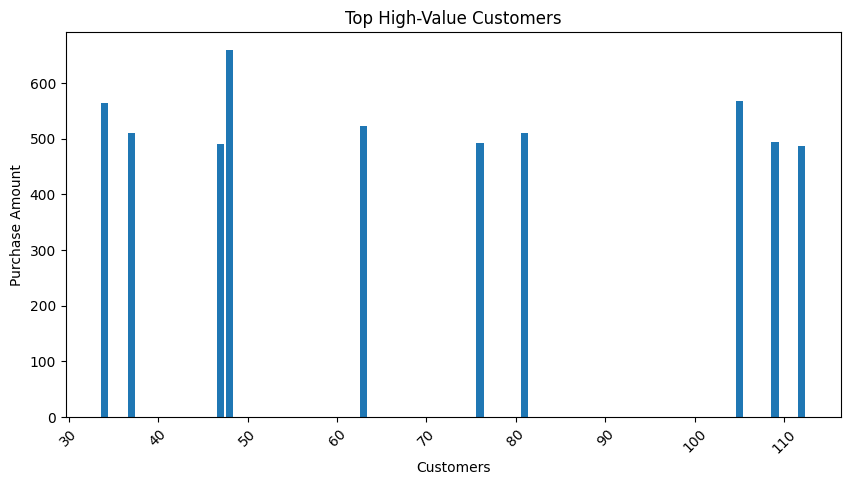

In [64]:
import matplotlib.pyplot as plt

top10 = high_value_customers.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["user_id"],
    top10["total_purchase_amount"]
)

plt.xticks(rotation=45)

plt.xlabel("Customers")

plt.ylabel("Purchase Amount")

plt.title("Top High-Value Customers")

plt.show()

In [66]:
# customer category
customer_summary["customer_category"] = "Regular"

customer_summary.loc[
    customer_summary["customer_score"] >= threshold,
    "customer_category"
] = "High Value"

In [67]:
customer_summary["customer_category"].value_counts()

customer_category
Regular       9000
High Value    1000
Name: count, dtype: int64

# Delayed Payment Detection

In [68]:
# discibe the payment distribution
customer_summary["avg_payment_delay"].describe()

count    10000.000000
mean         7.776250
std          7.417524
min          0.000000
25%          2.000000
50%          3.000000
75%         15.500000
max         25.000000
Name: avg_payment_delay, dtype: float64

In [69]:
# high payment delay customer 
delayed_customers = customer_summary[
    customer_summary["avg_payment_delay"] > 15
]

print(delayed_customers.head())

    user_id  total_logins  total_invoices  total_invoice_amount  \
7         8           3.0               2                227.34   
8         9          38.0               2                181.50   
9        10          33.0               2                192.78   
10       11          11.0               2                267.34   
11       12          31.0               2                175.79   

    avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
7                18.0                3                 164.06           0.0   
8                22.5                7                 348.07           0.0   
9                21.5                3                 173.74           0.0   
10               15.5                5                 228.28           0.0   
11               22.0                5                 202.98           0.0   

    total_tickets  open_tickets  avg_usage_hours  Cluster  \
7             2.0           0.0         1.474754        1   


In [70]:
# sort highest customer payment delayed
high_delay = customer_summary.sort_values(
    by="avg_payment_delay",
    ascending=False
)

print(high_delay.head(10))

      user_id  total_logins  total_invoices  total_invoice_amount  \
1725     1726          15.0               2                 96.08   
3839     3840          31.0               2                210.66   
4053     4054          32.0               2                122.27   
9479     9480          27.0               2                181.77   
8544     8545          22.0               2                199.62   
9574     9575          27.0               2                 89.38   
8560     8561          18.0               2                262.20   
7209     7210          30.0               2                152.08   
1015     1016          25.0               2                196.21   
520       521          28.0               2                251.50   

      avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
1725               25.0                3                 184.12           0.0   
3839               25.0                5                 288.26           0.0 

In [71]:
# risk catogry
def payment_risk(days):

    if days <= 5:
        return "Low Risk"

    elif days <= 15:
        return "Medium Risk"

    else:
        return "High Risk"


customer_summary["payment_risk"] = customer_summary[
    "avg_payment_delay"
].apply(payment_risk)

In [72]:
customer_summary["payment_risk"].value_counts()

payment_risk
Low Risk       5931
High Risk      2536
Medium Risk    1533
Name: count, dtype: int64

In [73]:
# analys
risk_analysis = customer_summary.groupby(
    "payment_risk"
)[[
    "total_purchase_amount",
    "total_logins",
    "total_tickets"
]].mean().round(2)

print(risk_analysis)

              total_purchase_amount  total_logins  total_tickets
payment_risk                                                    
High Risk                    333.00         21.62           1.44
Low Risk                     283.49         25.70           0.91
Medium Risk                  328.73         13.40           2.36


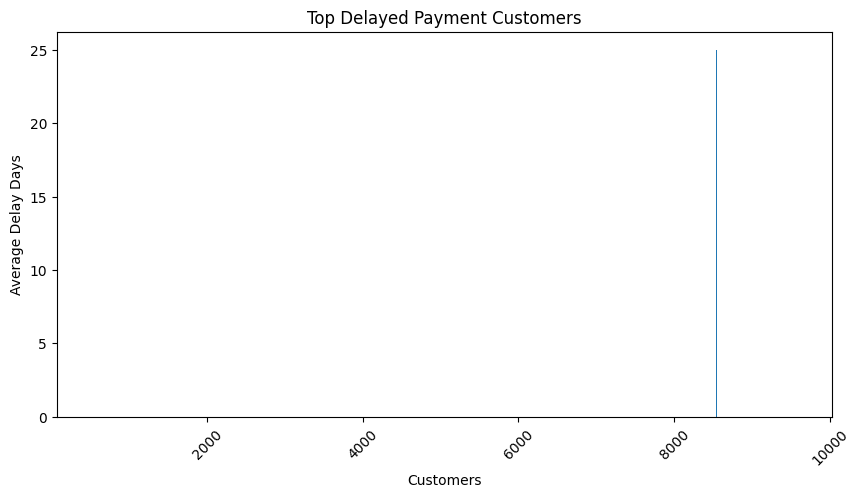

In [75]:
# visualise
import matplotlib.pyplot as plt

top10 = high_delay.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["user_id"],
    top10["avg_payment_delay"]
)

plt.xticks(rotation=45)

plt.xlabel("Customers")

plt.ylabel("Average Delay Days")

plt.title("Top Delayed Payment Customers")

plt.show()

In [78]:
# delay grater than 20 days
critical_customers = customer_summary[
    customer_summary["avg_payment_delay"] > 20
]

print(critical_customers[[
    "user_id",
    "avg_payment_delay"
]].head())

    user_id  avg_payment_delay
8         9               22.5
9        10               21.5
11       12               22.0
42       43               22.5
77       78               21.5


In [79]:
# delay 10 days
critical_customers = customer_summary[
    customer_summary["avg_payment_delay"] > 10
]

print(critical_customers[[
    "user_id",
    "avg_payment_delay"
]].head())

    user_id  avg_payment_delay
4         5               14.5
7         8               18.0
8         9               22.5
9        10               21.5
10       11               15.5


# complaints analysis

In [80]:
# discribe the tickets Statistics
customer_summary["total_tickets"].describe()

count    10000.000000
mean         1.264600
std          1.241346
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: total_tickets, dtype: float64

In [85]:
# customer complaints with more than 3
frequent_complaints = customer_summary[
    customer_summary["total_tickets"] > 3
]

print(frequent_complaints.head())

    user_id  total_logins  total_invoices  total_invoice_amount  \
21       22           8.0               2                244.55   
24       25           7.0               2                240.22   
39       40           9.0               2                218.57   
57       58          11.0               2                129.11   
71       72           6.0               2                163.61   

    avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
21               14.5                7                 437.03           0.0   
24               20.0                8                 385.39           0.0   
39                3.0                7                 430.94           0.0   
57                1.5                3                 176.01           0.0   
71               20.0                4                 215.47           0.0   

    total_tickets  open_tickets  avg_usage_hours  Cluster       Customer_Type  \
21            4.0           0.0         1

In [86]:
print("Total Frequent Complaint Users:")

print(frequent_complaints.shape[0])

Total Frequent Complaint Users:
871


In [87]:
# top complaints users
top_complaint_users = customer_summary.sort_values(
    by="total_tickets",
    ascending=False
)

print(top_complaint_users.head(10))

      user_id  total_logins  total_invoices  total_invoice_amount  \
5000     5001          11.0               2                126.21   
5073     5074           9.0               2                248.38   
918       919           8.0               2                192.77   
915       916          12.0               2                165.52   
914       915           6.0               2                132.18   
5054     5055          10.0               2                193.17   
5070     5071           8.0               2                200.71   
5071     5072           5.0               2                161.34   
5077     5078           7.0               2                208.23   
5166     5167           8.0               2                165.30   

      avg_payment_delay  total_purchases  total_purchase_amount  avg_discount  \
5000               15.0                6                 341.95           0.0   
5073                4.0                8                 495.04           0.0 

In [88]:
frequent_complaints[[
    "total_logins",
    "total_purchase_amount",
    "avg_payment_delay",
    "avg_usage_hours",
    "total_tickets"
]].describe()

,total_logins,total_purchase_amount,avg_payment_delay,avg_usage_hours,total_tickets
count,871.000000,871.000000,871.000000,871.000000,871.0
mean,7.548794,332.250103,9.244546,1.430478,4.0
std,2.884695,116.959303,6.084502,0.057729,0.0
min,0.000000,81.260000,0.000000,1.261475,4.0
25%,5.000000,236.745000,3.000000,1.392787,4.0
50%,7.000000,330.160000,9.000000,1.431475,4.0
75%,9.000000,419.470000,15.000000,1.468279,4.0
max,18.000000,648.650000,20.000000,1.637541,4.0


In [92]:
# complaint risk
def complaint_risk(tickets):

    if tickets <= 2:
        return "Low Complaints"

    elif tickets <= 5:
        return "Medium Complaints"

    else:
        return "High Complaints"


customer_summary["complaint_risk"] = customer_summary[
    "total_tickets"
].apply(complaint_level)

In [93]:
customer_summary["complaint_risk"].value_counts()

complaint_risk
Low Complaints       8293
Medium Complaints    1707
Name: count, dtype: int64

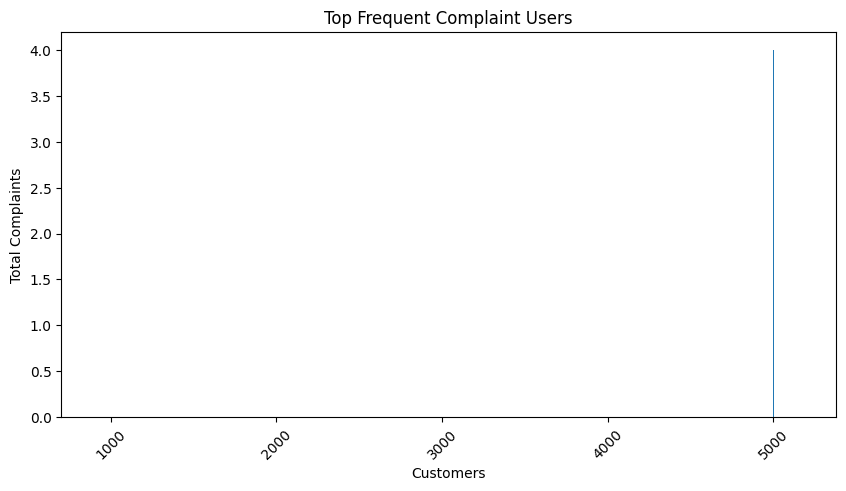

In [95]:
import matplotlib.pyplot as plt

top10 = top_complaint_users.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["user_id"],
    top10["total_tickets"]
)

plt.xticks(rotation=45)

plt.xlabel("Customers")

plt.ylabel("Total Complaints")

plt.title("Top Frequent Complaint Users")

plt.show()

# Trend Visualization

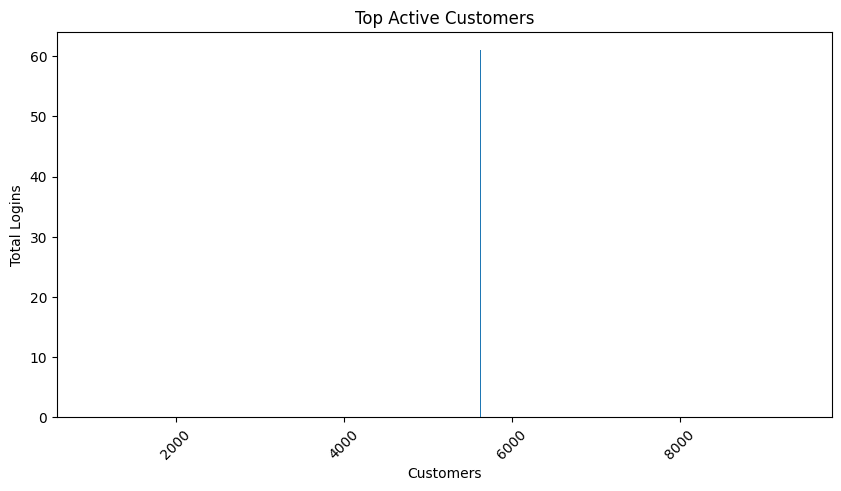

In [97]:
# login freqeuncy
import matplotlib.pyplot as plt

login_trend = customer_summary.sort_values(
    by="total_logins",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    login_trend["user_id"],
    login_trend["total_logins"]
)

plt.xticks(rotation=45)

plt.xlabel("Customers")

plt.ylabel("Total Logins")

plt.title("Top Active Customers")

plt.show()

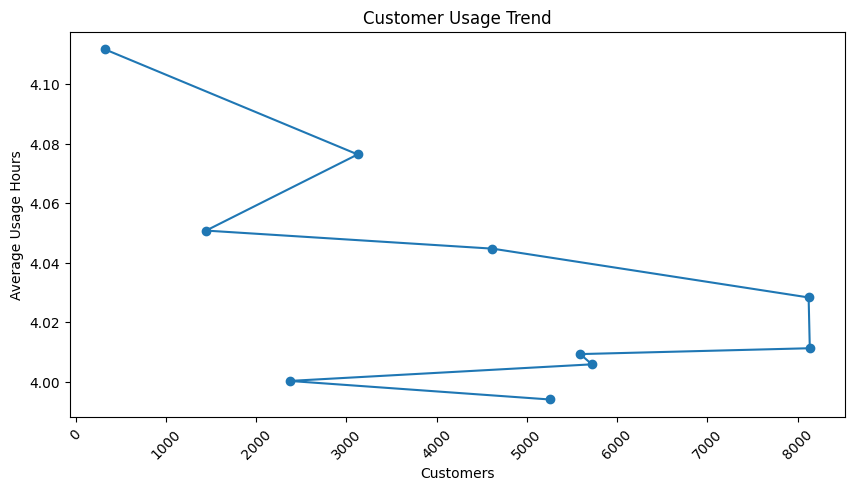

In [101]:
# usage trend
top_usage = customer_summary.sort_values(
    by="avg_usage_hours",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.plot(
    top_usage["user_id"],
    top_usage["avg_usage_hours"],
    marker='o'
)

plt.xticks(rotation=45)

plt.xlabel("Customers")

plt.ylabel("Average Usage Hours")

plt.title("Customer Usage Trend")

plt.show()

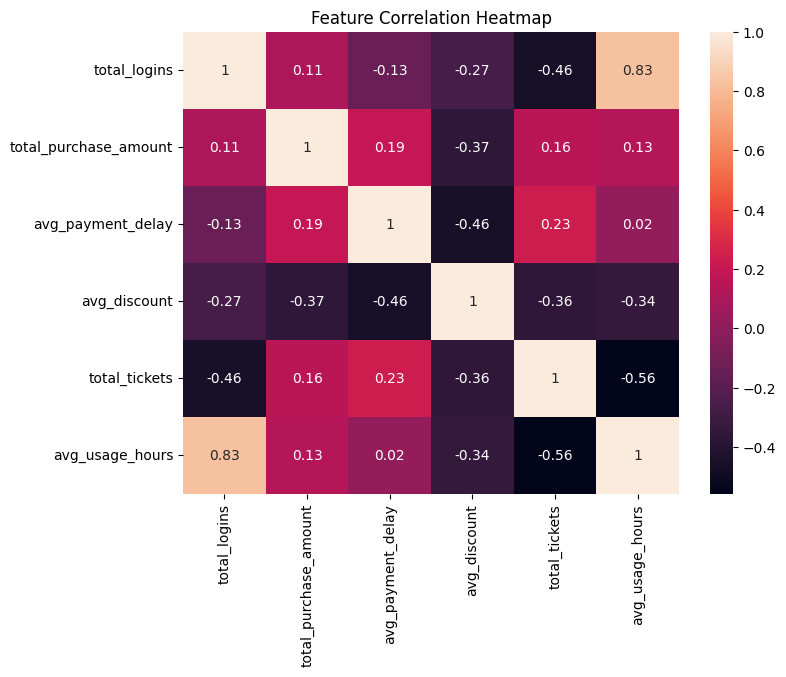

In [103]:
# correlation heatmap
import seaborn as sns

numeric_cols = customer_summary[[
    "total_logins",
    "total_purchase_amount",
    "avg_payment_delay",
    "avg_discount",
    "total_tickets",
    "avg_usage_hours"
]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [110]:
churn = pd.read_csv("churn.csv")

In [112]:
churn.head()

,user_id,username,logins_per_week,avg_payment_delay_days,discount_purchase_pct,total_complaints,open_complaints,recent_usage_hours,prior_usage_hours,churn
0,1,emily_smith_1,1.166667,0.0,0.0,3,2,12.09,75.46,0
1,2,karen_taylor_2,1.283333,3.5,100.0,0,0,55.67,57.02,0
2,3,jane_smith_3,0.700000,2.0,0.0,3,2,11.31,73.92,0
3,4,thomas_jackson_4,1.283333,1.5,100.0,0,0,55.80,64.66,0
4,5,james_smith_5,4.200000,14.5,0.0,2,0,94.74,90.65,0


In [107]:
final_df.isna().sum()

user_id                   0
username                  0
logins_per_week           0
avg_payment_delay_days    0
discount_purchase_pct     0
total_complaints          0
open_complaints           0
recent_usage_hours        0
prior_usage_hours         0
churn                     0
dtype: int64

In [108]:
final_df.duplicated().sum()

0

In [109]:
customer_summary.head()

,user_id,total_logins,total_invoices,total_invoice_amount,avg_payment_delay,total_purchases,total_purchase_amount,avg_discount,total_tickets,open_tickets,avg_usage_hours,Cluster,Customer_Type,customer_score,customer_category,payment_risk,complaint_level,complaint_risk
0,1,10.0,2,248.79,0.0,7,473.19,0.000000,3.0,0.0,1.435246,1,Inactive Customers,191.263049,Regular,Low Risk,Medium Complaints,Medium Complaints
1,2,11.0,2,258.85,3.5,4,163.22,15.652500,0.0,0.0,1.847377,2,Frequent Complaint Customers,67.507475,Regular,Low Risk,Low Complaints,Low Complaints
2,3,6.0,2,104.34,4.0,7,456.27,0.000000,3.0,0.0,1.397213,1,Inactive Customers,183.287443,Regular,Low Risk,Medium Complaints,Medium Complaints
3,4,11.0,2,160.03,1.5,6,306.39,16.246667,0.0,0.0,1.974754,2,Frequent Complaint Customers,125.000951,Regular,Low Risk,Low Complaints,Low Complaints
4,5,36.0,2,262.04,14.5,6,284.92,0.000000,2.0,0.0,3.039180,3,Delayed Payment Customers,120.125836,Regular,Medium Risk,Low Complaints,Low Complaints


In [113]:
 customer_df= customer_summary.drop(['Customer_Type', 'customer_category', 'payment_risk', 'complaint_level','complaint_risk'], axis=1)

In [115]:
customer_df.head()

,user_id,total_logins,total_invoices,total_invoice_amount,avg_payment_delay,total_purchases,total_purchase_amount,avg_discount,total_tickets,open_tickets,avg_usage_hours,Cluster,customer_score
0,1,10.0,2,248.79,0.0,7,473.19,0.000000,3.0,0.0,1.435246,1,191.263049
1,2,11.0,2,258.85,3.5,4,163.22,15.652500,0.0,0.0,1.847377,2,67.507475
2,3,6.0,2,104.34,4.0,7,456.27,0.000000,3.0,0.0,1.397213,1,183.287443
3,4,11.0,2,160.03,1.5,6,306.39,16.246667,0.0,0.0,1.974754,2,125.000951
4,5,36.0,2,262.04,14.5,6,284.92,0.000000,2.0,0.0,3.039180,3,120.125836


In [116]:
customer_df['churn'] = churn['churn']

In [117]:
customer_df

,user_id,total_logins,total_invoices,total_invoice_amount,avg_payment_delay,total_purchases,total_purchase_amount,avg_discount,total_tickets,open_tickets,avg_usage_hours,Cluster,customer_score,churn
0,1,10.0,2,248.79,0.0,7,473.19,0.000000,3.0,0.0,1.435246,1,191.263049,0
1,2,11.0,2,258.85,3.5,4,163.22,15.652500,0.0,0.0,1.847377,2,67.507475,0
2,3,6.0,2,104.34,4.0,7,456.27,0.000000,3.0,0.0,1.397213,1,183.287443,0
3,4,11.0,2,160.03,1.5,6,306.39,16.246667,0.0,0.0,1.974754,2,125.000951,0
4,5,36.0,2,262.04,14.5,6,284.92,0.000000,2.0,0.0,3.039180,3,120.125836,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,13.0,2,225.27,1.0,4,208.81,23.432500,0.0,0.0,2.060820,2,86.436164,0
9996,9997,4.0,2,278.30,8.0,4,254.77,0.000000,2.0,0.0,1.355738,1,101.979148,1
9997,9998,5.0,2,204.76,4.0,6,478.83,0.000000,2.0,0.0,1.350820,1,192.202164,1
9998,9999,29.0,2,172.49,2.0,8,510.50,0.642500,1.0,0.0,3.523443,0,210.404689,0


# customer churn prediction model

In [143]:
customer_df["churn"] = 0

customer_df.loc[
    (
        (customer_df["total_logins"] < 15) &
        (customer_df["avg_usage_hours"] < 2.5)
    )
    |
    (
        (customer_df["avg_payment_delay"] > 12)
    )
    |
    (
        (customer_df["total_tickets"] > 3)
    ),
    "churn"
] = 1

In [144]:
customer_df["churn"].value_counts()

churn
1    6460
0    3540
Name: count, dtype: int64

In [145]:
# 6460 likely to churn
# 3540 active

In [162]:
# input feature
X = customer_df[
[
    "total_invoice_amount",
    "total_purchase_amount",
    "avg_discount",
    "open_tickets",
    "avg_usage_hours"
]]

In [163]:
# target feature
y = customer_df['churn']

In [164]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [165]:
# apply random forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=41
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=41)

In [166]:
y_pred = model.predict(X_test)

In [167]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8895


In [ ]:
# here accuracy score is 88 

In [168]:
# confusion matrics
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 540  161]
 [  60 1239]]


In [169]:
# classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83       701
           1       0.89      0.95      0.92      1299

    accuracy                           0.89      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.89      0.89      0.89      2000



In [170]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
4        avg_usage_hours    0.624284
2           avg_discount    0.213970
1  total_purchase_amount    0.084432
0   total_invoice_amount    0.077314
3           open_tickets    0.000000


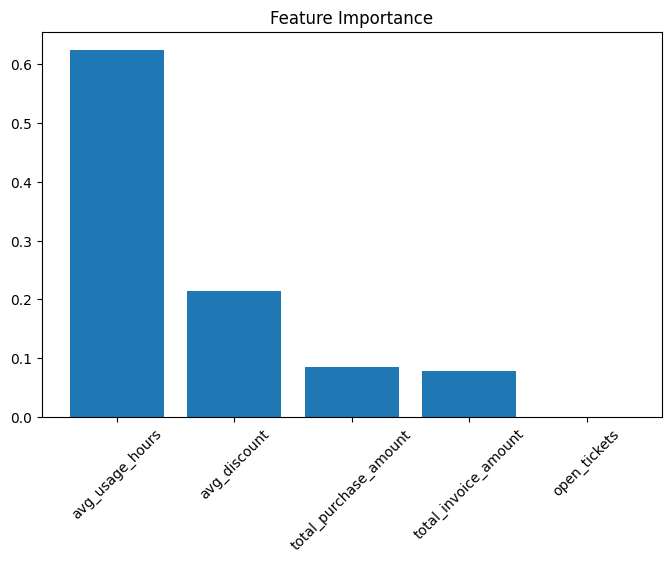

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()